In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
dataset = pd.read_csv('IDS_dataset.csv')

In [3]:
# Handle missing values by filling them with the column mean
dataset.fillna(method="bfill", inplace=True)

# Drop duplicate rows
dataset.drop_duplicates(inplace=True)

In [4]:
# Separate features and target
X = dataset.drop(columns=['class']).values  # Features
y = dataset['class'].values  # Target

In [5]:
# Encode categorical features
def Multilabelencoder(X, k):
    from sklearn.preprocessing import LabelEncoder
    X[:, k] = LabelEncoder().fit_transform(X[:, k])
    return X

# categorical features are in columns 1 to 3
for i in range(1, 4):
    X = Multilabelencoder(X, i)

In [6]:
# Encode the target variable
y = LabelEncoder().fit_transform(y)

In [7]:
# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
# Feature selection (select top 8 features based on ANOVA F-value)
selector = SelectKBest(score_func=f_classif, k=8)
X = selector.fit_transform(X, y)

# Print selected feature indices
selected_features = selector.get_support(indices=True)
print("Selected feature indices:", selected_features)

Selected feature indices: [ 3 11 24 28 32 33 37 38]


In [8]:
# Split the dataset into training and testing sets (70:30 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Print the shapes of the resulting datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (17634, 41)
X_test shape: (7558, 41)
y_train shape: (17634,)
y_test shape: (7558,)


In [9]:
# Import necessary libraries for models and evaluation
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Initialize models
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
rf = RandomForestClassifier(random_state=42)
bagging = BaggingClassifier(random_state=42)
adaboost = AdaBoostClassifier(random_state=42)
gboost = GradientBoostingClassifier(random_state=42)

# Train models
xgb.fit(X_train, y_train)
rf.fit(X_train, y_train)
bagging.fit(X_train, y_train)
adaboost.fit(X_train, y_train)
gboost.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

XGBoost Accuracy: 1.00
XGBoost Confusion Matrix:
[[3506   10]
 [  10 4032]]


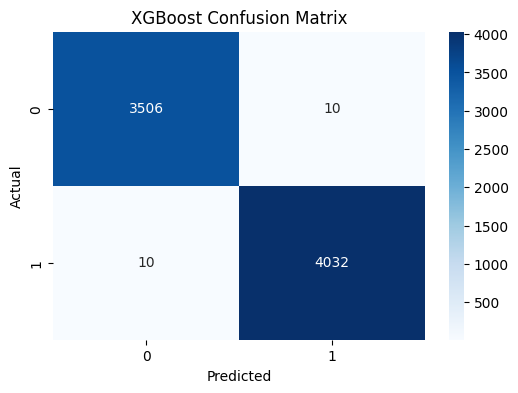

Random Forest Accuracy: 1.00
Random Forest Confusion Matrix:
[[3504   12]
 [   6 4036]]


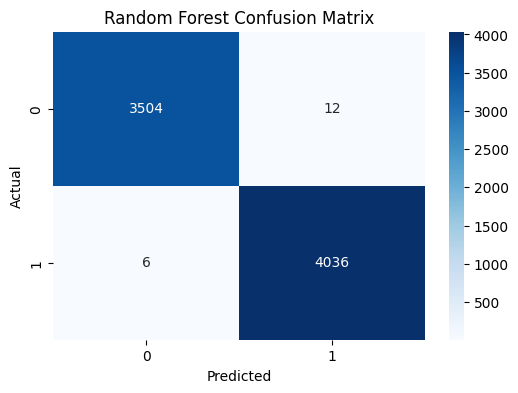

Bagging Classifier Accuracy: 1.00
Bagging Classifier Confusion Matrix:
[[3508    8]
 [  16 4026]]


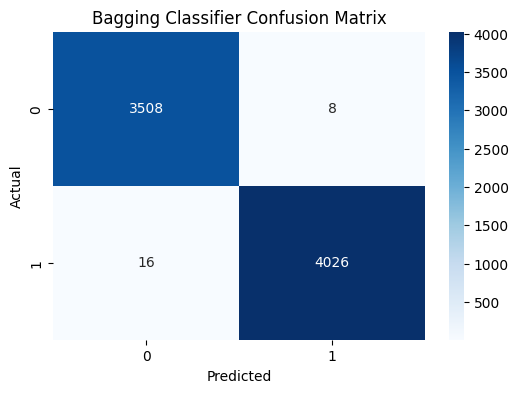

AdaBoost Accuracy: 0.98
AdaBoost Confusion Matrix:
[[3428   88]
 [  76 3966]]


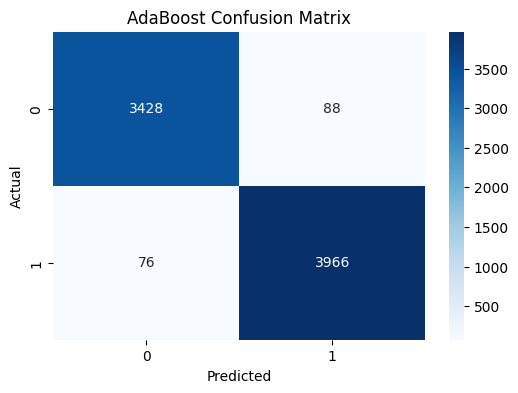

Gradient Boosting Accuracy: 1.00
Gradient Boosting Confusion Matrix:
[[3498   18]
 [  15 4027]]


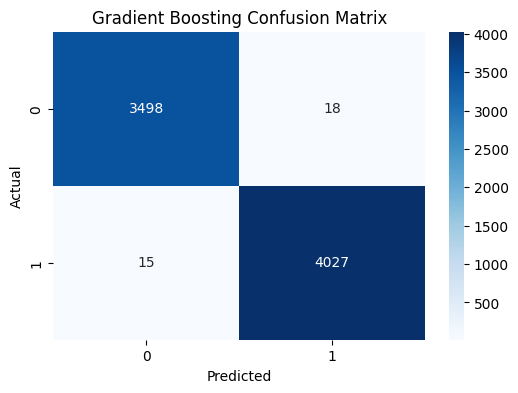

In [11]:
# Function to evaluate a model
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"{model_name} Accuracy: {acc:.2f}")
    print(f"{model_name} Confusion Matrix:\n{cm}")
    
    # Plot confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Evaluate each model
evaluate_model(xgb, X_test, y_test, "XGBoost")
evaluate_model(rf, X_test, y_test, "Random Forest")
evaluate_model(bagging, X_test, y_test, "Bagging Classifier")
evaluate_model(adaboost, X_test, y_test, "AdaBoost")
evaluate_model(gboost, X_test, y_test, "Gradient Boosting")

Voting Classifier Accuracy: 0.96
Voting Classifier Confusion Matrix:
[[3287  229]
 [ 111 3931]]


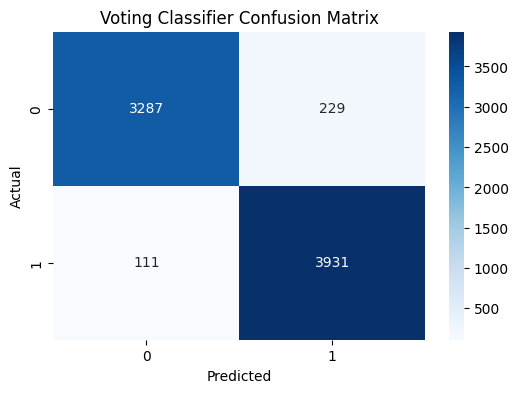

In [13]:
# Create a VotingClassifier with all models
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', xgb),
        ('rf', rf),
        ('bagging', bagging),
        ('adaboost', adaboost),
        ('gboost', gboost)
    ],
    voting='hard'
)

# Train VotingClassifier
voting_clf.fit(X_train, y_train)

# Evaluate VotingClassifier
evaluate_model(voting_clf, X_test, y_test, "Voting Classifier")